<font color="green"> <b><h1>Ejercicio 1</h1></b> </font>

<p>Descomposición de la Serie de Tiempo: Comienza descomponiendo la serie de
tiempo en sus componentes principales: tendencia, estacionalidad y residuos. Utiliza
métodos como el suavizamiento exponencial o la descomposición estacional para
comprender la estructura subyacente de los datos.</p>

In [39]:
### Primero importamos librerías y dataset

# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Herramientas de Series de Tiempo
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm # Para hallar hiperparámetros p, d, q con el modelo auto_arima

# Métricas de evaluación
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Importar dataset
try:
    # parse_dates=True convierte la columna de fechas en un formato temporal inteligente
    # index_col=0 asume que la primera columna tiene las fechas y la vuelve el índice
    df = pd.read_excel('Sales_Data.xlsx', index_col=0, parse_dates=True)
    print("Datos cargados exitosamente.")
    display(df.head())
except FileNotFoundError:
    print("Error: No se encontró el archivo 'Sales_Data.xlsx'. Verifica la ruta.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Datos cargados exitosamente.


,Sales
Order Date,
2015-01-01,14205.707
2015-02-01,4519.892
2015-03-01,55205.797
2015-04-01,27906.855
2015-05-01,23644.303


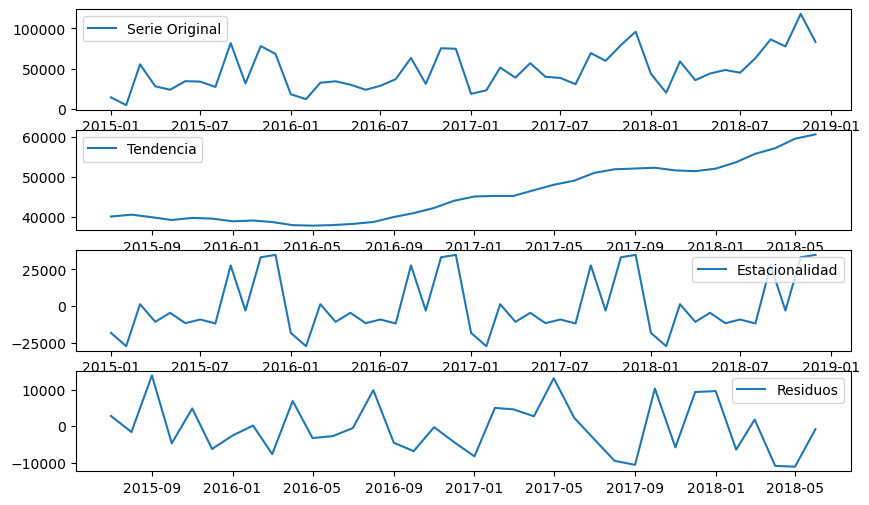

In [40]:
# Primero, creamos una copia del DataFrame
df_copy = df

# Descomponer la serie de tiempo en componentes
result = seasonal_decompose(df_copy['Sales'], model='additive')

# Graficar los componentes

plt.figure(figsize=(10, 6)) #Crear la figura de plots

# Graficar serie original
plt.subplot(4, 1, 1)
plt.plot(df_copy['Sales'], label='Serie Original')
plt.legend()

# Graficar Tendencia
plt.subplot(4, 1, 2)
plt.plot(result.trend, label='Tendencia')
plt.legend()

# Graficar Estacionalidad
plt.subplot(4, 1, 3)
plt.plot(result.seasonal, label='Estacionalidad')
plt.legend()

# Graficar Residuos
plt.subplot(4, 1, 4)
plt.plot(result.resid, label='Residuos')
plt.legend()

# Mostrar figura con gráficos.
plt.show()

<font color="orange"><h2> Conclusiones ejercicio 1 </h2></font>

<p>De los gráficos, se puede observar:</p>

<ul>
    <li>El gráfico de tendencia muestra una ligera tendencia a la baja de 2015 a mediados de 2016 y una marcada tendencia al alza, casi lineal, desde mediados de 2016 hasta 2019. Esto nos da indicios de que tendremos que utilizar diferenciación. Lo mismo será comprobado en el ejercicio 2 usando el test de Dickey-Fuller.</li>
    <li>El gráfico de estacionalidad muestra un claro aumento en las ventas durante el mes de diciembre en cada año y una baja de ventas presumiblemente en febrero de cada año; pero las estacionalidad parecen constantes cada año. Estas estacionalidades regulares nos absuelta de la necesidad de utilizar transformación logarítmica.</li>
    <li>No hay mucho que analizar de los residuos. La gráfica se ve normal, como una escalera.</li>
</ul>

<font color="green"> <b><h1>Ejercicio 2</h1></b> </font>

<p>Identificación de Parámetros ARIMA: Utiliza las funciones de autocorrelación (ACF) y
autocorrelación parcial (PACF) para identificar los posibles valores de los parámetros
p (orden del término autorregresivo) y q (orden del término de media móvil) en el 
modelo ARIMA. Además, realiza el test de Dickey-Fuller para determinar si es
necesario aplicar la diferenciación (valor d) para lograr la estacionaridad.</p>

In [41]:
### Primero, aplicamos el test de Dickey-Fuller.

# Aplicamos el test a la columna de ventas
test_ADF = adfuller(df_copy['Sales'], autolag='AIC')

# Contraste de hipótesis.
print("Contraste de hipótesis:")
print("-"*50)
print("\t H0: La serie no es estacionaria (Lo más normal en el mundo real)")
print('\t H1: La serie es estacionaria (Caso "anormal")')
print("-"*50)

# Mostramos resultados
print("Estadístico ADF:", test_ADF[0])
print("p-valor:", test_ADF[1])
print("Número de rezagos usados:", test_ADF[2])
print("Número de observaciones usadas:", test_ADF[3])
print("Valores críticos:")
for clave, valor in test_ADF[4].items():
    print(f"{clave}: {valor}")

print("\nConclusión sobre estacionariedad:")
# Interpretación básica
if test_ADF[1] <= 0.05:
    print("\tLa serie es probablemente estacionaria (rechazamos H0).")
else:
    print("\tNo se puede rechazar H0: la serie parece no estacionaria.")

Contraste de hipótesis:
--------------------------------------------------
	 H0: La serie no es estacionaria (Lo más normal en el mundo real)
	 H1: La serie es estacionaria (Caso "anormal")
--------------------------------------------------
Estadístico ADF: -4.416136761430769
p-valor: 0.00027791039276670623
Número de rezagos usados: 0
Número de observaciones usadas: 47
Valores críticos:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064

Conclusión sobre estacionariedad:
	La serie es probablemente estacionaria (rechazamos H0).


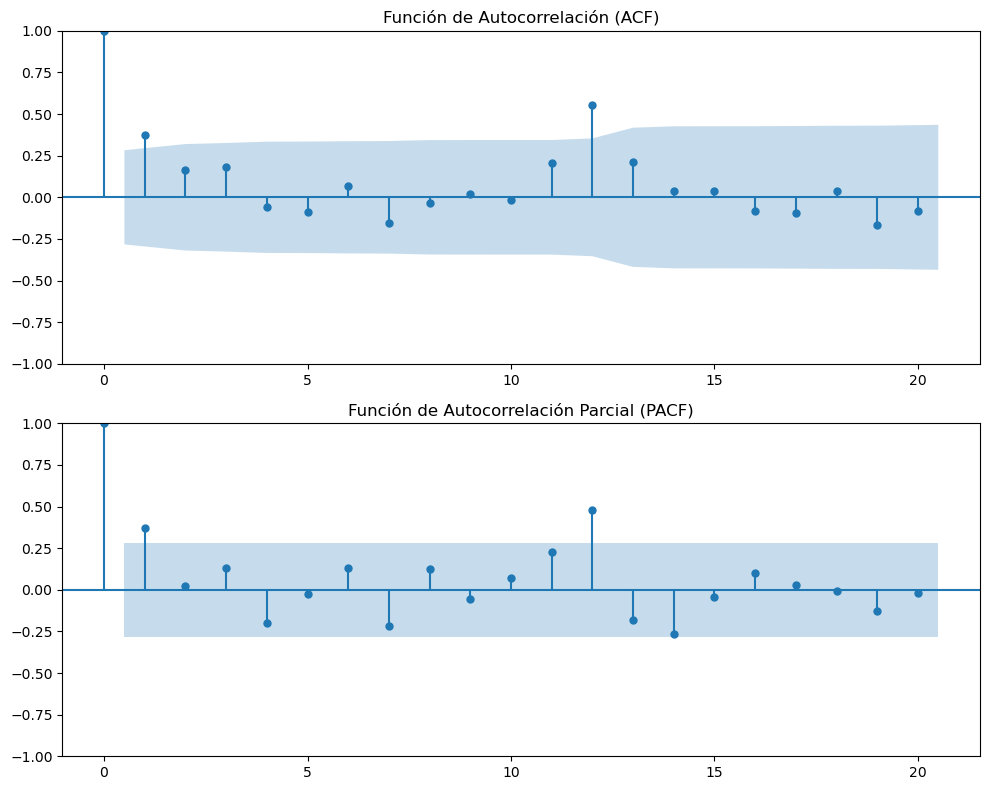

In [42]:
### Aplicamos ACF y PACF para hallar posibles valores de p y q en el modelo ARIMA

# Creamos una figura con 2 subgráficos (2 filas, 1 columna)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Graficamos ACF en el primer espacio (axes[0])
plot_acf(df_copy['Sales'], lags=20, ax=axes[0]) # La serie tiene 48 datos. Para evitar sobreajuste, cargamos la función con algo menos de la mitad.
axes[0].set_title("Función de Autocorrelación (ACF)")

# Graficamos PACF en el segundo espacio (axes[1])
plot_pacf(df_copy['Sales'], lags=20, ax=axes[1])
axes[1].set_title("Función de Autocorrelación Parcial (PACF)")

# Ajustamos los espacios y mostramos
plt.tight_layout()
plt.show()

<font color="orange"><h2>Conclusión ejercicio 2</h2></font>

<p>Una vez graficadas las funciones de Autocorrelación y autocorrelación parcial, además del test de contraste de hipótesis de Dickey-Fuller, podemos concluir lo siguiente sobre los valores iniciales de los hiperparámetros p, d y q del modelo ARIMA:</p>

<ul>
    <li> <b>Sobre AR(p):</b> La función de autocorrelación parcial (PACF) es la que está relacionada con el modelo autorregresivo por considerar parcialmente los valores pasados para predecir valores futuros, de modo que el modelo sea más limpio y sencillo computacionalmente y de entender. En su gráfico, la PACF, muestra dos barritas que sobresalen claramente de la zona oscurecida. Como la zona oscurecida contiene el error aceptado, esas dos barritas representan la necesidad de aplicar el modelo autorregresivo (AR) con dos rezagos (o lags) en ARIMA, es decir, <b>p=2</b>.</li>
    <li> <b>Sobre MA(q):</b> La función de autocorrelación (AFC) es la que está relacionada con el modelo de Medias o promedios Móviles por considerar todos los errores pasados para predecir valores futuros, de modo que el ruido generado sea tomado en cuenta como outlier y de este modo adquirir mayor precisión en la predicción. En su gráfico, la ACF, muestra dos barritas que sobresalen claramente de la zona oscurecida. La cual, al igual que en el gráfico anterior, determina que es necesario aplicar este modelo con un rezago de 2 (2 lags) en el ARIMA. Por lo cual, <b>q=2</b> </li>
    <li> <b>Sobre el test de contraste de hipótesis de Dickey-Fuller (Diferenciación): </b> En el test D-F se obtuvo un <em>valor p</em> (o <em>p-value</em>) <b>menor a 0.05</b>, o menos al 5%. Esto indica que lo más probable es que estemos ante una situación "anormal", puesto que se contrastan dos hipótesis, una nula (<em>H<sub>0</sub></em>) que corresponde a la hipótesis más esperable o más "aburrida" en la mayoría de los casos. En este en particular, que la serie sea no estacionaria (La mayoría de los datos del mundo real forman una serie no estacionaria). Mientras que la hipótesis alternativa (<em>H<sub>1</sub></em>) contiene el caso anormal o "divertido" en la mayoría de los casos. En este en particular, indica que la serie es estacionaria. El <em>p-valor</em> indica qué tan probable es que el resultado sea "normal" y, por convención se establece que si es menor a 0.05, nos encontramos ante un caso anormal. Como en nuestro test el <em>p-valor</em> es muy pequeño (Aproximadamente <em>0.0028</em>) esto indica que estamos ante un caso anormal, es decir, consideramos la hipótesis alternativa (<em>H<sub>1</sub>: Serie estacionaria</em>), que implica que no hace falta utilizar diferenciación en el modelo ARIMA para hacer que la serie se parezca a una estacionaria. Por lo tanto, <b>d=0</b> </li>
</ul>

<font color="green"> <b><h1>Ejercicio 3</h1></b> </font>

<p>Modelado con ARIMA: Aplica el modelo ARIMA utilizando los parámetros
identificados en el paso anterior. Ajusta el modelo a los datos históricos de ventas
mensuales y realiza predicciones para los próximos meses.</p>

C:\Users\ruben\anaconda3\envs\ADL\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ruben\anaconda3\envs\ADL\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ruben\anaconda3\envs\ADL\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


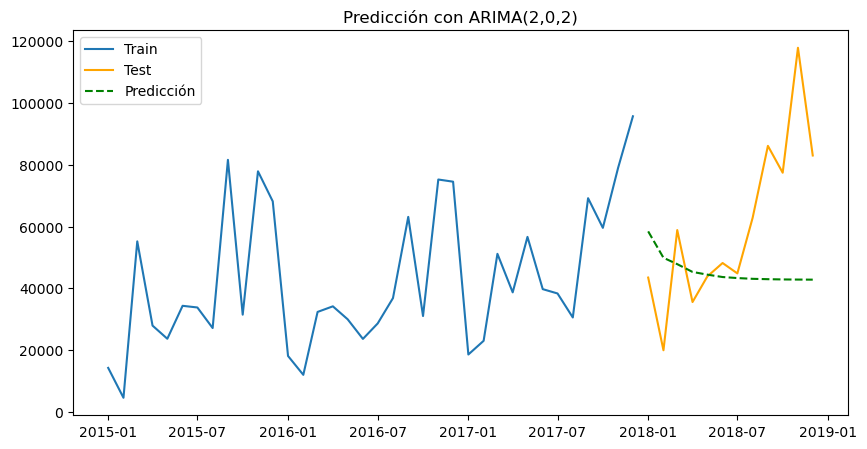

In [43]:
### Entrenamiento del modelo con Arima con p=2, q=2

# Usaremos los últimos 12 registros como test
train = df_copy.iloc[:-12]   # Todo menos los últimos 12
df_test = df_copy.iloc[-12:] # Últimos 12 registros

# Entrenar ARIMA con parámetros conocidos de AR, Diferenciación y MA.
# orden = (p, d, q)
modelo_arima = ARIMA(train["Sales"], order=(2, 0, 2))
modelo_fit = modelo_arima.fit()

# Predicciones
predicciones_arima = modelo_fit.forecast(steps=len(df_test))

# Combinar resultados
df_arima = df_test.copy()
df_arima["prediccion"] = predicciones_arima.values

# Visualización
plt.figure(figsize=(10, 5))
plt.plot(train.index, train["Sales"], label="Train")
plt.plot(df_arima.index, df_arima["Sales"], label="Test", color="orange")
plt.plot(df_arima.index, predicciones_arima, label="Predicción", color="green", linestyle="--")
plt.legend()
plt.title("Predicción con ARIMA(2,0,2)")
plt.show()

C:\Users\ruben\anaconda3\envs\ADL\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ruben\anaconda3\envs\ADL\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ruben\anaconda3\envs\ADL\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ruben\anaconda3\envs\ADL\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\ruben\anaconda3\envs\ADL\Lib\site-packages

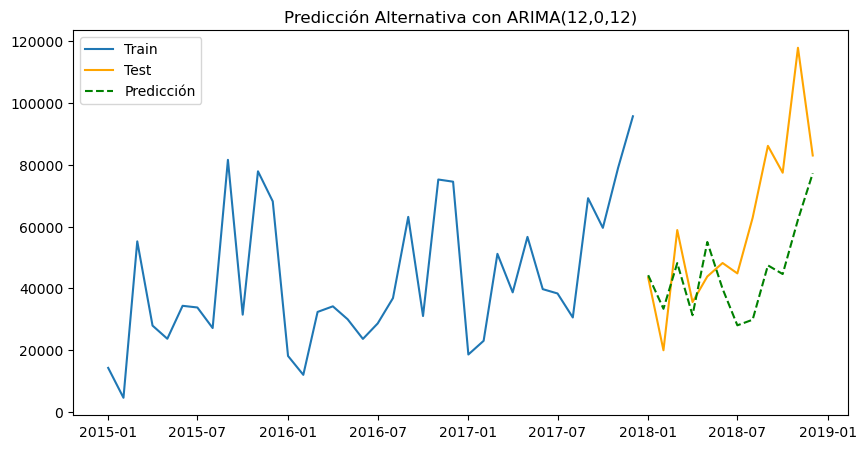

In [44]:
### Entrenamiento del modelo con Arima con p=12, q=12

# Usaremos los últimos 12 registros como test
train = df_copy.iloc[:-12]   # Todo menos los últimos 12
df_test = df_copy.iloc[-12:] # Últimos 12 registros

# Entrenar ARIMA con parámetros conocidos de AR, Diferenciación y MA.
# orden = (p, d, q)
modelo_arima_alt = ARIMA(train["Sales"], order=(12, 0, 12))
modelo_arima_alt_fit = modelo_arima_alt.fit()

# Predicciones
predicciones_arima_alt = modelo_arima_alt_fit.forecast(steps=len(df_test))

# Combinar resultados
df_arima_alt = df_test.copy()
df_arima_alt["prediccion"] = predicciones_arima_alt.values

# Visualización
plt.figure(figsize=(10, 5))
plt.plot(train.index, train["Sales"], label="Train")
plt.plot(df_arima_alt.index, df_arima_alt["Sales"], label="Test", color="orange")
plt.plot(df_arima_alt.index, predicciones_arima_alt, label="Predicción", color="green", linestyle="--")
plt.legend()
plt.title("Predicción Alternativa con ARIMA(12,0,12)")
plt.show()

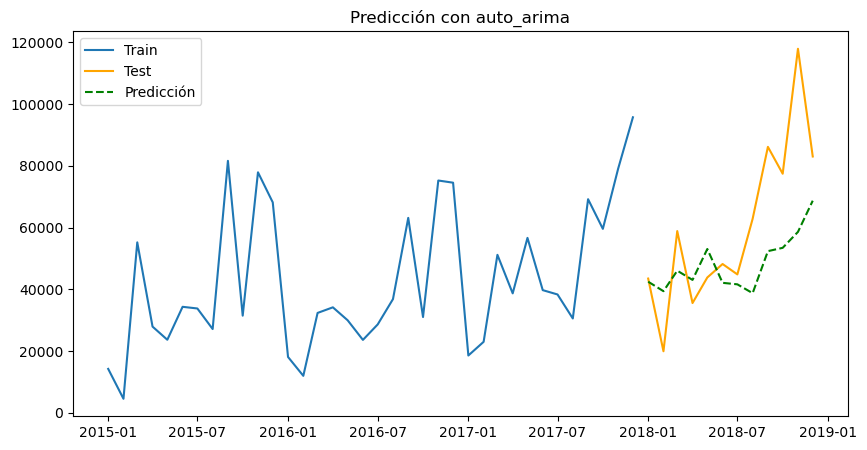

In [45]:
# Entrenar modelo auto_arima
# stepwise=True hace búsqueda más rápida de parámetros
modelo_auto = pm.auto_arima(
    train["Sales"],
    seasonal=True,      # Hay estacionalidad
    stepwise=True,
    suppress_warnings=True,
    m=12
)

# Predicciones
predicciones_auto = modelo_auto.predict(n_periods=len(df_test))

# Crear DataFrame con predicciones y test
df_auto = df_test.copy()
df_auto["prediccion"] = predicciones_auto

# --- Visualización ---
plt.figure(figsize=(10, 5))
plt.plot(train.index, train["Sales"], label="Train")
plt.plot(df_auto.index, df_auto["Sales"], label="Test", color="orange")
plt.plot(df_auto.index, predicciones_auto, label="Predicción", color="green", linestyle="--")
plt.legend()
plt.title("Predicción con auto_arima")
plt.show()

C:\Users\ruben\anaconda3\envs\ADL\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ruben\anaconda3\envs\ADL\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ruben\anaconda3\envs\ADL\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\ruben\anaconda3\envs\ADL\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


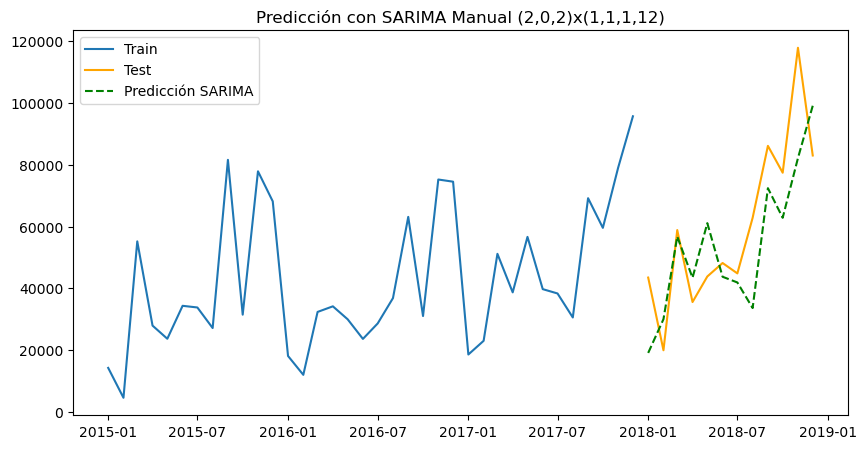

In [46]:
### Entrenar modelo SARIMA

# Primero debemos importar la herramienta específica para SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Entrenar SARIMA manual con parámetros normales y estacionales
# Order = (p, d, q) | Seasonal_order = (P, D, Q, m)
modelo_sarima = SARIMAX(train["Sales"], 
                        order=(2, 0, 2), 
                        seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

# Ajustamos el modelo (disp=False oculta los mensajes de texto del entrenamiento)
modelo_sarima_fit = modelo_sarima.fit(disp=False)

# Predicciones
predicciones_sarima = modelo_sarima_fit.forecast(steps=len(df_test))

# --- Visualización ---
plt.figure(figsize=(10, 5))
plt.plot(train.index, train["Sales"], label="Train")
plt.plot(df_test.index, df_test["Sales"], label="Test", color="orange")
plt.plot(df_test.index, predicciones_sarima, label="Predicción SARIMA", color="green", linestyle="--")
plt.legend()
plt.title("Predicción con SARIMA Manual (2,0,2)x(1,1,1,12)")
plt.show()

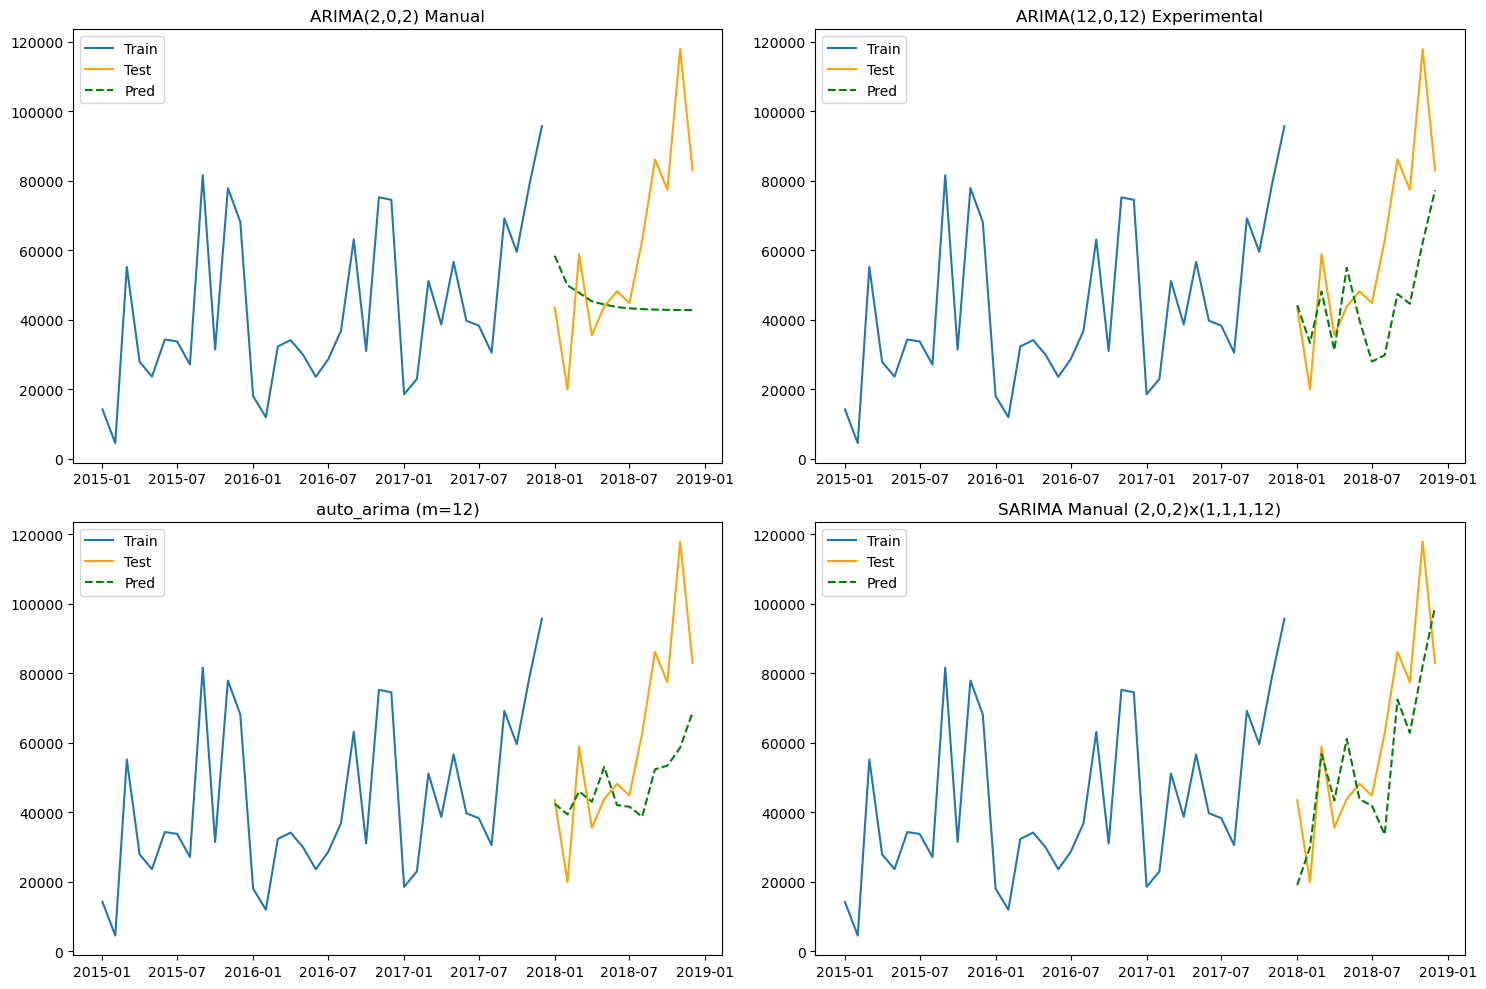

In [47]:
### Visualizar todos los modelos juntos

# Crear una figura con una cuadrícula de 2 filas por 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico 1: ARIMA manual (2,0,2) [Fila 0, Columna 0]
axes[0, 0].plot(train.index, train["Sales"], label="Train")
axes[0, 0].plot(df_test.index, df_test["Sales"], label="Test", color="orange")
axes[0, 0].plot(df_test.index, predicciones_arima, label="Pred", color="green", linestyle="--")
axes[0, 0].set_title("ARIMA(2,0,2) Manual")
axes[0, 0].legend()

# Gráfico 2: ARIMA(12,0,12) [Fila 0, Columna 1]
axes[0, 1].plot(train.index, train["Sales"], label="Train")
axes[0, 1].plot(df_test.index, df_test["Sales"], label="Test", color="orange")
axes[0, 1].plot(df_test.index, predicciones_arima_alt, label="Pred", color="green", linestyle="--")
axes[0, 1].set_title("ARIMA(12,0,12) Experimental")
axes[0, 1].legend()

# Gráfico 3: auto_arima [Fila 1, Columna 0]
axes[1, 0].plot(train.index, train["Sales"], label="Train")
axes[1, 0].plot(df_test.index, df_test["Sales"], label="Test", color="orange")
axes[1, 0].plot(df_test.index, predicciones_auto, label="Pred", color="green", linestyle="--")
axes[1, 0].set_title("auto_arima (m=12)")
axes[1, 0].legend()

# Gráfico 4: SARIMA [Fila 1, Columna 1]
axes[1, 1].plot(train.index, train["Sales"], label="Train")
axes[1, 1].plot(df_test.index, df_test["Sales"], label="Test", color="orange")
axes[1, 1].plot(df_test.index, predicciones_sarima, label="Pred", color="green", linestyle="--")
axes[1, 1].set_title("SARIMA Manual (2,0,2)x(1,1,1,12)")
axes[1, 1].legend()

# Ajustar los espacios para que los títulos no se pisen y mostrar
plt.tight_layout()
plt.show()

<font color="orange"> <h2>Conclusiones ejercicio 3</h2> </font>

<p>Se realizaron varios modelos para comparar visualmente las predicciones y, en el siguiente ejercicio, comparar las métricas de error de cada uno.</p>

<ul>
    <li>En el gráfico de ARIMA(2,0,2) se puede observar una predicción exageradamente estacionaria para nuestro caso, pero es la más confiable matemáticamente debido a los datos consegidos por ACF, PACF y el test Dickey-Fuller.</li>
    <li>Se creó un modelo experimental ARIMA(12,0,12) para forzar sobreajuste y comparar métricas y visualización.</li>
    <li>Se creó un modelo con <em>auto_arima</em>, que obtiene automáticamente los hiperparámetros p, d y q. En este caso, se le dio un m=12, que indica que va a leer datos de hasta los 12 meses anteriores, puesto que la estacionalidad de nuestra serie es parecida cada año.</li>
    <li>Se creó un modelo SARIMA con los mismos datos obtenidos en la ACF y la PACF con test Dickey-Fuller para comparar ARIMA(2,0,2) con un modelo más optimizado para trabajar con Series Temporales estacionarias.</li>
</ul>




<font color="green"> <b><h1>Ejercicio 4</h1></b> </font>

<p>Evaluación de Predicciones: Divide los datos históricos en un conjunto de
entrenamiento y uno de prueba. Utiliza el conjunto de entrenamiento para ajustar el
modelo ARIMA y luego evalúa las predicciones en el conjunto de prueba. Calcula
métricas de evaluación como el error cuadrático medio (MSE) o el error absoluto
medio (MAE) para medir el rendimiento del modelo</p>

In [48]:
### Calcular y visualizar métricas

# Guardamos los valores reales del test para no repetir código
y_true = df_test["Sales"]

# Creamos una función rápida para calcular todo de una vez
def calcular_metricas(y_real, y_pred, aic_val):
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)
    return {"AIC": aic_val, "MSE": mse, "RMSE": rmse, "MAE": mae}

# Recopilamos los datos de los 4 modelos
# Nota: statsmodels usa .aic, pero auto_arima (pmdarima) usa .aic()
tabla_resultados = {
    "ARIMA(2,0,2) Manual": calcular_metricas(y_true, predicciones_arima, modelo_fit.aic),
    "ARIMA(12,0,12) Experimental": calcular_metricas(y_true, predicciones_arima_alt, modelo_arima_alt_fit.aic),
    "auto_arima (m=12)": calcular_metricas(y_true, predicciones_auto, modelo_auto.aic()),
    "SARIMA(2,0,2)x(1,1,1,12)": calcular_metricas(y_true, predicciones_sarima, modelo_sarima_fit.aic)
}

# Convertimos a DataFrame, transponemos (.T) para que los modelos sean las filas, y ordenamos de menor a mayor AIC
df_metricas = pd.DataFrame(tabla_resultados).T
df_metricas = df_metricas.sort_values(by="AIC", ascending=True)

# Mostramos la tabla redondeando a 2 decimales para que se vea limpia
display(df_metricas.round(2))

,AIC,MSE,RMSE,MAE
"SARIMA(2,0,2)x(1,1,1,12)",205.23,3.237431e+08,17992.86,14878.41
auto_arima (m=12),819.74,5.632064e+08,23731.97,17909.76
"ARIMA(2,0,2) Manual",833.90,1.006361e+09,31723.19,23773.95
"ARIMA(12,0,12) Experimental",852.02,6.330507e+08,25160.50,19297.59


<font color=orange> <h2>Conclusiones ejercicio 4</h2> </font>

<p>Podemos observar rápidamente varias conclusiones:</p>

<ul>
    <li>El modelo <b>ARIMA(2,0,2)</b> peca de no saber manejar la estacionalidad que se puede observar en la separación de componentes de nuestra serie temporal. Esto lo castiga con el error cuadrático medio (MSE) más alto y un AIC que apenas lo salva de ser el peor modelo.</li>
    <li>El modelo <b>ARIMA(12,0,12)</b> está sobreajustado. Logra un MSE del nivel del Auto Arima y el SARIMA, sin embargo, ese mismo sobreajuste lo castiga en el AIC. Consideremos que el Modelo AIC se asemeja al F1-Score, en el sentido que busca el equilibrio entre dos conceptos, concretamente, el equilibrio entre bondad de ajuste y complejidad. Como el ARIMA(12,0,12) es innecesariamente complejo, el AIC se dispara, desenmascarando su sobreajuste.</li>
    <li>El modelo <b>Auto Arima</b> brilla por su sencillez. Es como haber aplicado GridSearch para hallar los mejores hiperparámetros de un modelo haciendo múltiples validaciones cruzadas, pero Auto Arima conserva el factor cronológico de los datos para hallar esos hiperparámetros ideales. Esto le otorga el error y el AIC más bajo entre los modelos de ARIMA tradicionales.</li>
    <li>El modelo <b>SARIMA</b> es uno especializado en series de tiempo estacionales. Conserva el orden de los datos (p, d, q) de ARIMA, pero agrega hiperparámetros de estacionalidad (P, D, Q, m), que técnicamente indican lo mismo que los anteriores en nuestro caso, pero agrega un factor importante: m es el tiempo donde se presenta esa estacionalidad. En nuestra serie temporal, había una estacionalidad que se presentaba cada año: Aumento de ventas en diciembre. Además de una Tendencia: Las ventas iban al alza. Con esto en consideración, el modelo, que es mejor para tratar la estacionariedad y tendencias dentro de estacionalidades regulares, triunfó con una métrica AIC al rededor de 4 veces menor que el promedio del resto y un error considerablemente menor.</li>
</ul>

<p>De lo anterior, podemos concluir que el modelo SARIMA es el más recomendable y confiable en este escenario debido a sus métricas. el AIC indica equilibrio alto entre qué tan buena es su predicción (bondad de ajuste) y penalización por complejidad (qué tantos cálculos requiere realizar para predcir), mientras que el error que presenta es el menor entre todos los modelos comparados.</p>

<p>Como el MAE es 14.878 dólares, eso significa que, en promedio, nuestra predicción de las ventas puede estar 14.878 dólares por encima o por debajo de lo esperado cada mes, lo cual permite tomar mejores decisiones estratégicas, principalmente sobre stock. Por ejemplo, decidir comprar suficientes productos como para estar preparados en caso de tener ventas de 14.878 dólares más, y de ese modo tener stock suficiente para evitar perder ventas.</p>